<a href="https://colab.research.google.com/github/Jirtus-sanasam/MLP-Diabetes/blob/main/DiabetesDT1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [29]:
df = pd.read_csv('/content/diabetes_data2.csv')

In [30]:
# Replacing 0 as null value
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df[cols] = df[cols].replace(0, np.nan)

In [31]:
# Imputing Null Value with KNNImputer
from sklearn.impute import KNNImputer
knn_imputer = KNNImputer(n_neighbors=5)
df[cols] = knn_imputer.fit_transform(df[cols])

In [32]:
# Cap outliers using IQR
def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)
    return df

for col in df.columns[:-1]:  # exclude target
    df = cap_outliers(df, col)

In [33]:
# FEATURE ENGINEERING

# --- 1. Interaction Features ---
df['Glucose_BMI'] = df['Glucose'] * df['BMI']
df['Glucose_Insulin'] = df['Glucose'] * df['Insulin']
df['BMI_Age'] = df['BMI'] * df['Age']
df['Insulin_SkinThickness'] = df['Insulin'] * df['SkinThickness']

# --- 2. Ratio Features (avoid division by zero) ---
df['Glucose_Insulin_Ratio'] = df['Glucose'] / (df['Insulin'] + 1e-6)
df['BMI_Age_Ratio'] = df['BMI'] / (df['Age'] + 1e-6)

# --- 3. Polynomial Features ---
df['Glucose_sq'] = df['Glucose'] ** 2
df['BMI_sq'] = df['BMI'] ** 2
df['Age_sq'] = df['Age'] ** 2

# --- 4. Age Binning ---
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0, 30, 45, 60, 100],
    labels=['Young', 'Middle', 'Senior', 'Elderly']
)

# One-hot encoding with integer output
df = pd.get_dummies(df, columns=['Age_Group'], drop_first=True, dtype=int)

# --- 5. BMI Category ---
df['BMI_Category'] = pd.cut(
    df['BMI'],
    bins=[0, 18.5, 24.9, 29.9, 100],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

df = pd.get_dummies(df, columns=['BMI_Category'], drop_first=True, dtype=int)

# --- 6. Glucose Category ---
df['Glucose_Level'] = pd.cut(
    df['Glucose'],
    bins=[0, 99, 125, 300],
    labels=['Normal', 'Prediabetes', 'Diabetes']
)

df = pd.get_dummies(df, columns=['Glucose_Level'], drop_first=True, dtype=int)

# --- 7. Insulin Resistance (HOMA-IR) ---
df['HOMA_IR'] = (df['Glucose'] * df['Insulin']) / 405

# --- 8. Pregnancy Risk Flag ---
df['High_Pregnancies'] = (df['Pregnancies'] > 3).astype(int)

# --- 9. Log Transform (handle skewness) ---
df['Log_Insulin'] = np.log1p(df['Insulin'])
df['Log_DiabetesPedigreeFunction'] = np.log1p(df['DiabetesPedigreeFunction'])

# --- 10. Composite Risk Score ---
df['Risk_Score'] = (
    (df['Glucose'] / 100) +
    (df['BMI'] / 25) +
    (df['Age'] / 50) +
    (df['DiabetesPedigreeFunction'])
)

# --- 11. Final Safety Check (convert any leftover bool → int) ---
bool_cols = df.select_dtypes(include='bool').columns
if not bool_cols.empty:
    for col in bool_cols.unique(): # Iterate over unique column names
        # Ensure we are only trying to convert actual boolean columns that might still exist
        if df[col].dtype == 'bool':
            df[col] = df[col].astype(int)

# --- 12. Verify Data Types ---
print(df.dtypes)


Pregnancies                     float64
Glucose                         float64
BloodPressure                   float64
SkinThickness                   float64
Insulin                         float64
BMI                             float64
DiabetesPedigreeFunction        float64
Age                             float64
Outcome                           int64
Glucose_BMI                     float64
Glucose_Insulin                 float64
BMI_Age                         float64
Insulin_SkinThickness           float64
Glucose_Insulin_Ratio           float64
BMI_Age_Ratio                   float64
Glucose_sq                      float64
BMI_sq                          float64
Age_sq                          float64
Age_Group_Middle                  int64
Age_Group_Senior                  int64
Age_Group_Elderly                 int64
BMI_Category_Normal               int64
BMI_Category_Overweight           int64
BMI_Category_Obese                int64
Glucose_Level_Prediabetes         int64


In [36]:
X = df.drop('Outcome', axis=1)
Y = df['Outcome']

print(f"Starting features: {X.shape[1]}")

Starting features: 30


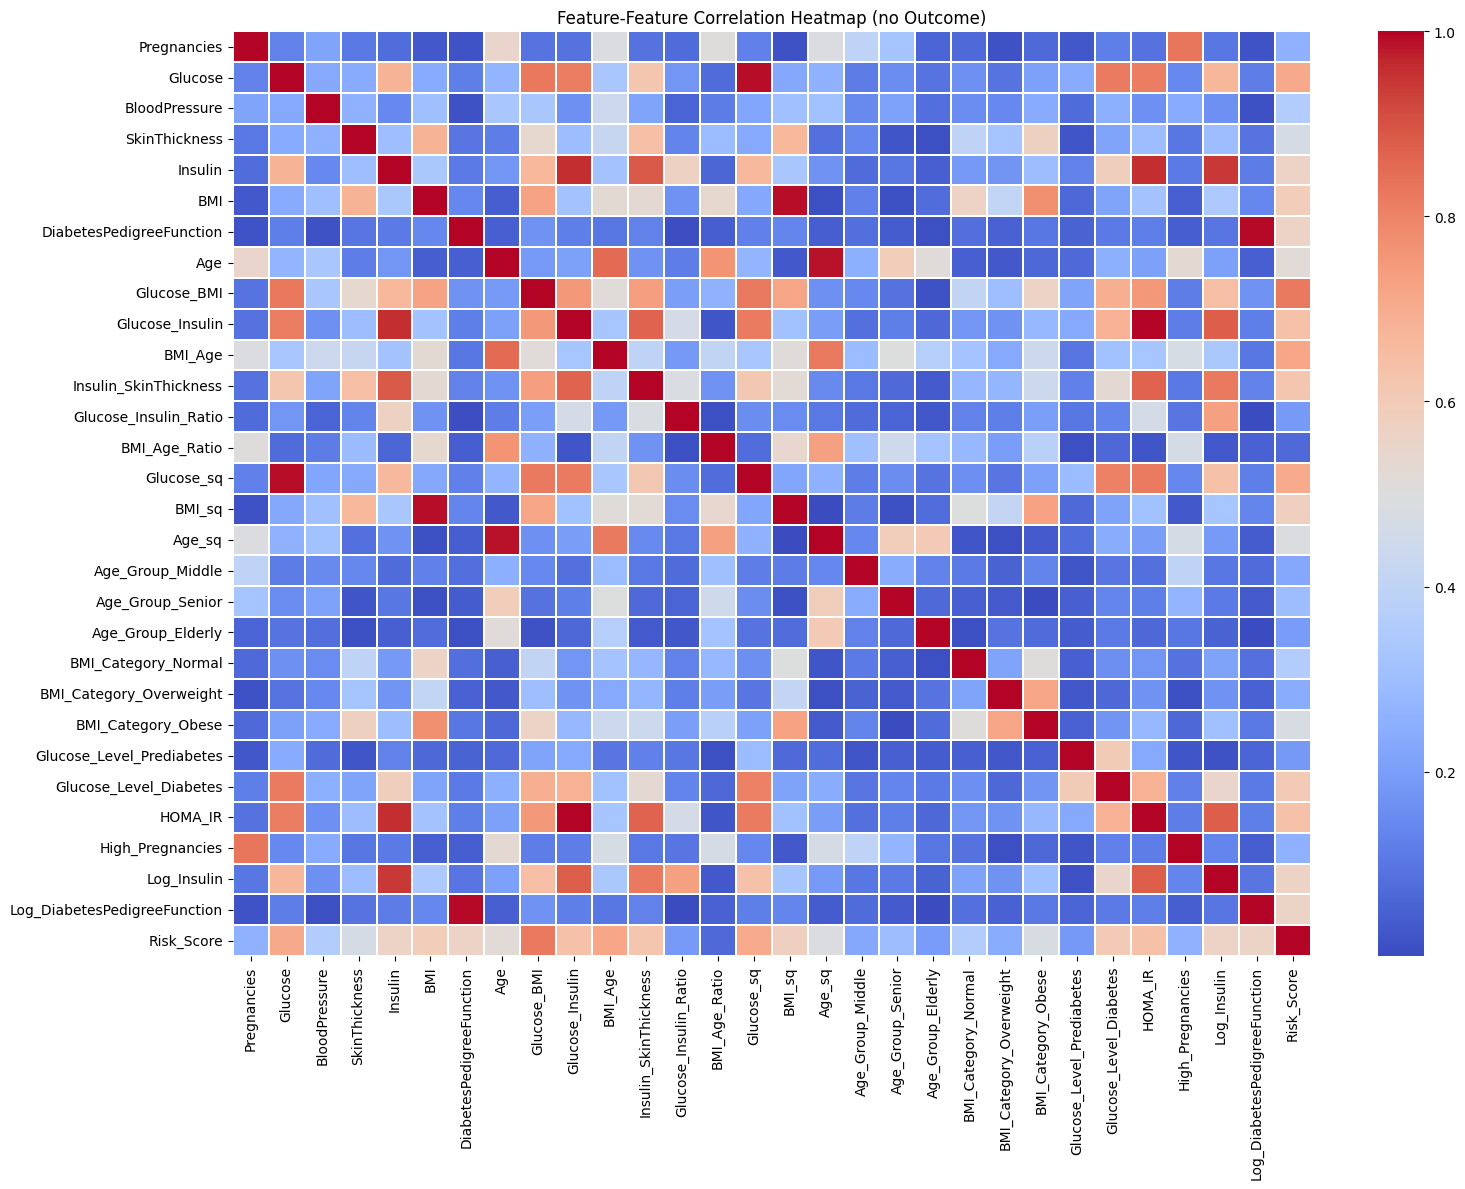


Dropping highly correlated features: ['Glucose_Insulin', 'Glucose_sq', 'BMI_sq', 'Age_sq', 'HOMA_IR', 'Log_Insulin', 'Log_DiabetesPedigreeFunction']
Features after correlation filter: 23


In [37]:
corr_matrix = X.corr().abs()   # <-- X only, Outcome excluded

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.3)
plt.title("Feature-Feature Correlation Heatmap (no Outcome)")
plt.tight_layout()
plt.show()

# Upper triangle to avoid duplicate pairs
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop_corr = [col for col in upper.columns if any(upper[col] > 0.90)]
print(f"\nDropping highly correlated features: {to_drop_corr}")

X = X.drop(columns=to_drop_corr)
print(f"Features after correlation filter: {X.shape[1]}")

In [38]:
# --- Step C: Variance Threshold (X only, NO Outcome) ---
# Goal: drop features with almost no variation across samples

from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0.01)
vt.fit(X)   # <-- X only, Outcome excluded

low_var_cols = X.columns[~vt.get_support()].tolist()
print(f"Dropping low-variance features: {low_var_cols}")

X = X[X.columns[vt.get_support()]]
print(f"Features after variance filter: {X.shape[1]}")

Dropping low-variance features: []
Features after variance filter: 23


In [39]:
# STEP 1: TRAIN/TEST SPLIT
# ============================================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")
print(f"Train class balance:\n{y_train.value_counts()}")

Train size : (614, 23)
Test size  : (154, 23)
Train class balance:
Outcome
0    400
1    214
Name: count, dtype: int64


In [40]:
# STEP 2: SCALING (fit on train only)
# ============================================================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)      # NEVER fit on test

# Keep as DataFrame for later use (SHAP, feature names)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns)

In [41]:
# STEP 3: HANDLE CLASS IMBALANCE (SMOTE on train only)
# ============================================================
# pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE : {pd.Series(y_train).value_counts().to_dict()}")
print(f"After SMOTE  : {pd.Series(y_train_res).value_counts().to_dict()}")

Before SMOTE : {0: 400, 1: 214}
After SMOTE  : {0: 400, 1: 400}


In [42]:
# ============================================================
# STEP 4: BUILD MLP MODEL
# ============================================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Dropout, BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

def build_mlp(input_dim):
    model = Sequential([

        # --- Input block ---
        Dense(128, input_dim=input_dim, kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        Dropout(0.3),

        # --- Hidden block 1 ---
        Dense(64, kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        Dropout(0.3),

        # --- Hidden block 2 ---
        Dense(32, kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        Dropout(0.2),

        # --- Output ---
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    return model

model = build_mlp(input_dim=X_train_res.shape[1])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,337 (56.00 KB)

 Trainable params: 13,889 (54.25 KB)

 Non-trainable params: 448 (1.75 KB)

In [43]:
# ============================================================
# STEP 5: CALLBACKS
# ============================================================

early_stop = EarlyStopping(
    monitor='val_auc',
    patience=20,
    restore_best_weights=True,  # rolls back to best epoch automatically
    mode='max',
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,          # halve the LR when plateau hit
    patience=10,
    min_lr=1e-6,
    verbose=1
)

In [44]:
# ============================================================
# STEP 6: TRAIN
# ============================================================

history = model.fit(
    X_train_res, y_train_res,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print(f"\nTraining stopped at epoch: {early_stop.stopped_epoch}")

Epoch 1/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.6094 - auc: 0.6723 - loss: 0.8456 - precision: 0.4855 - recall: 0.7000 - val_accuracy: 0.6812 - val_auc: 0.0000e+00 - val_loss: 0.7506 - val_precision: 1.0000 - val_recall: 0.6812 - learning_rate: 0.0010
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7234 - auc: 0.7876 - loss: 0.7336 - precision: 0.6171 - recall: 0.6917 - val_accuracy: 0.6750 - val_auc: 0.0000e+00 - val_loss: 0.6986 - val_precision: 1.0000 - val_recall: 0.6750 - learning_rate: 0.0010
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7672 - auc: 0.8252 - loss: 0.6802 - precision: 0.6888 - recall: 0.6917 - val_accuracy: 0.6750 - val_auc: 0.0000e+00 - val_loss: 0.6894 - val_precision: 1.0000 - val_recall: 0.6750 - learning_rate: 0.0010
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7500 - auc: 0.8122 - loss: 0.6929 - precision: 0.6739 - recall: 0.6458 - val_accuracy: 0.6687 - val_auc: 0.0000e+00 - val_loss

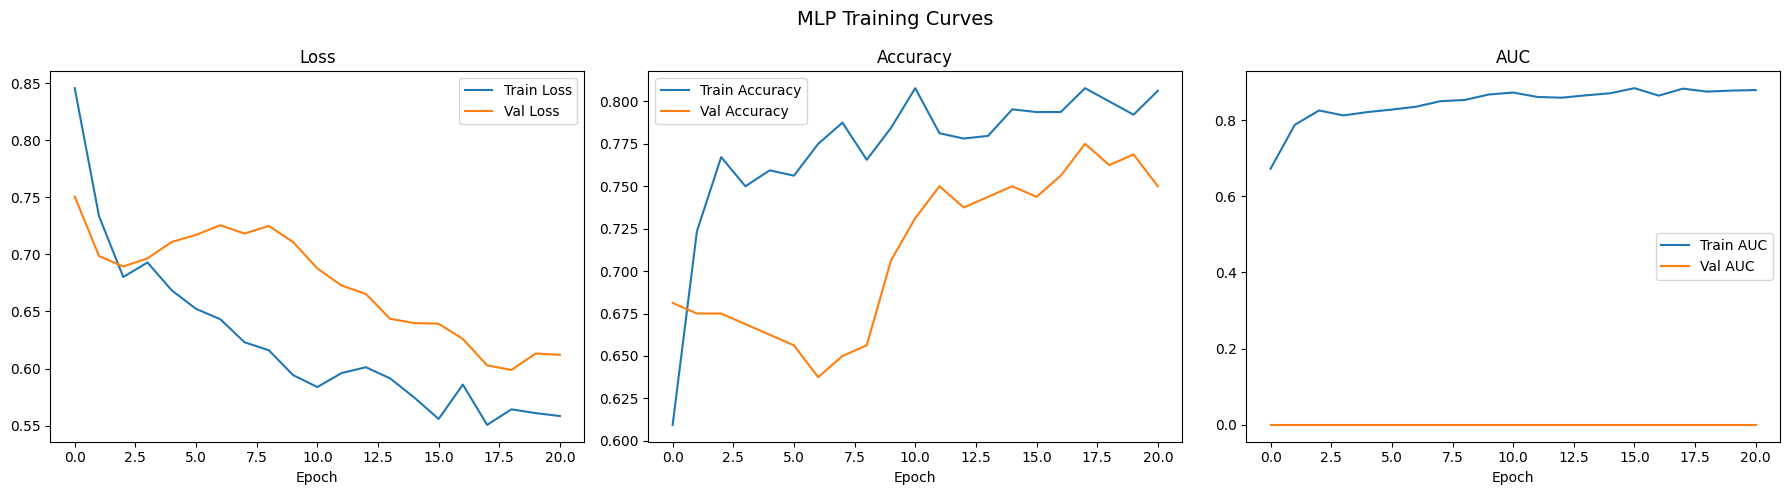

In [45]:
# ============================================================
# STEP 7: PLOT TRAINING CURVES
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# Accuracy
axes[1].plot(history.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

# AUC
axes[2].plot(history.history['auc'],     label='Train AUC')
axes[2].plot(history.history['val_auc'], label='Val AUC')
axes[2].set_title('AUC')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.suptitle('MLP Training Curves', fontsize=14)
plt.tight_layout()
plt.show()

In [46]:
# ============================================================
# STEP 8: EVALUATE ON TEST SET
# ============================================================
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
    f1_score, matthews_corrcoef
)

y_proba = model.predict(X_test_scaled).flatten()
y_pred  = (y_proba >= 0.5).astype(int)

print("=" * 45)
print("         MLP EVALUATION ON TEST SET")
print("=" * 45)
print(f"  Accuracy         : {accuracy_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC          : {roc_auc_score(y_test, y_proba):.4f}")
print(f"  F1 Score         : {f1_score(y_test, y_pred):.4f}")
print(f"  MCC              : {matthews_corrcoef(y_test, y_pred):.4f}")
print("=" * 45)
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['No Diabetes', 'Diabetes']))

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 189ms/step
         MLP EVALUATION ON TEST SET
  Accuracy         : 0.7013
  ROC-AUC          : 0.7765
  F1 Score         : 0.5893
  MCC              : 0.3556

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.78      0.75      0.77       100
    Diabetes       0.57      0.61      0.59        54

    accuracy                           0.70       154
   macro avg       0.68      0.68      0.68       154
weighted avg       0.71      0.70      0.70       154



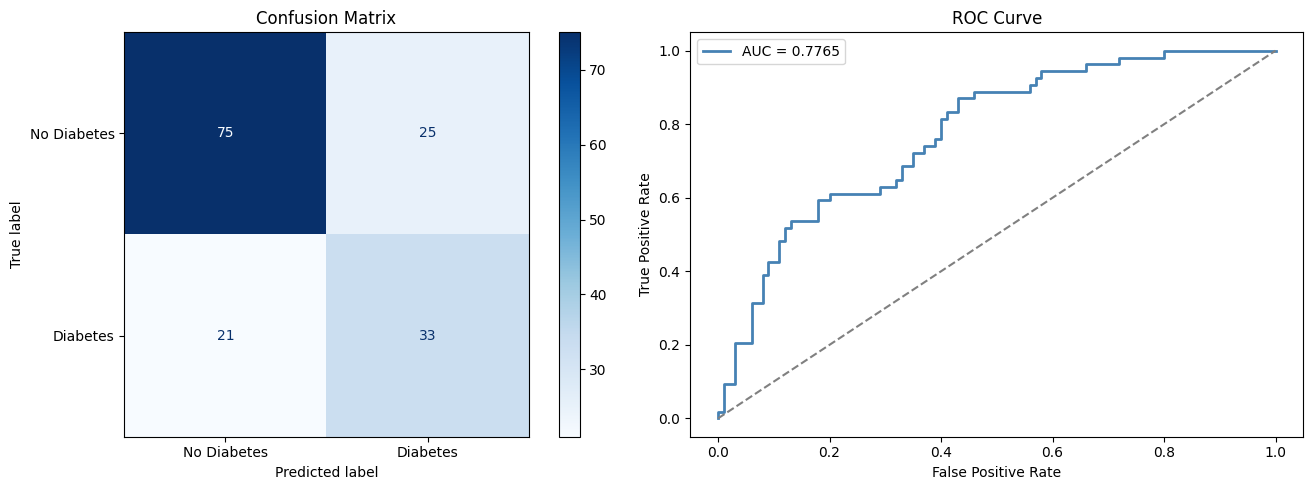

In [47]:
# ============================================================
# STEP 9: CONFUSION MATRIX + ROC CURVE
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Diabetes','Diabetes'])\
    .plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, _ = __import__('sklearn.metrics', fromlist=['roc_curve'])\
    .roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.4f}",
             color='steelblue', lw=2)
axes[1].plot([0,1],[0,1],'--', color='gray')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

Optimal threshold: 0.4394
Accuracy  @ optimal threshold : 0.6753
F1 Score  @ optimal threshold : 0.6528
              precision    recall  f1-score   support

 No Diabetes       0.89      0.57      0.70       100
    Diabetes       0.52      0.87      0.65        54

    accuracy                           0.68       154
   macro avg       0.71      0.72      0.67       154
weighted avg       0.76      0.68      0.68       154



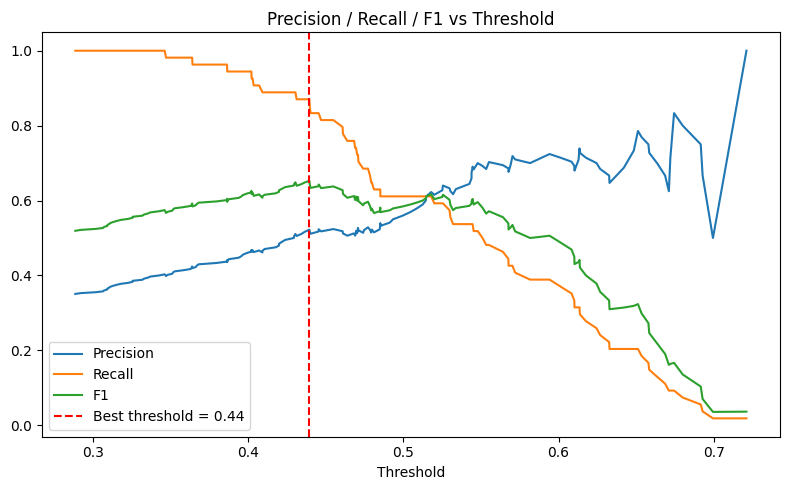

In [48]:
# ============================================================
# STEP 10: FIND OPTIMAL THRESHOLD (important for medical data)
# ============================================================
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# F1 at each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal threshold: {best_threshold:.4f}")

# Re-evaluate with optimal threshold
y_pred_opt = (y_proba >= best_threshold).astype(int)
print(f"Accuracy  @ optimal threshold : {accuracy_score(y_test, y_pred_opt):.4f}")
print(f"F1 Score  @ optimal threshold : {f1_score(y_test, y_pred_opt):.4f}")
print(classification_report(y_test, y_pred_opt,
      target_names=['No Diabetes','Diabetes']))

# Plot Precision-Recall curve
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1],    label='Recall')
plt.plot(thresholds, f1_scores[:-1],  label='F1')
plt.axvline(best_threshold, color='red', linestyle='--',
            label=f'Best threshold = {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.title('Precision / Recall / F1 vs Threshold')
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
# ============================================================
# XGBOOST MODEL - DIABETES PREDICTION
# ============================================================
# !pip install xgboost
import xgboost as xgb
from xgboost import XGBClassifier

In [50]:
# ============================================================
# STEP 1: COMPUTE CLASS WEIGHT FOR IMBALANCE
# ============================================================
# XGBoost handles imbalance natively via scale_pos_weight
# Formula: count(negative class) / count(positive class)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"Negative class : {neg}")
print(f"Positive class : {pos}")
print(f"scale_pos_weight : {scale_pos_weight:.4f}")

Negative class : 400
Positive class : 214
scale_pos_weight : 1.8692


In [51]:
# ============================================================
# STEP 2: BUILD XGBOOST MODEL
# ============================================================

xgb_model = XGBClassifier(
    n_estimators      = 500,       # max trees (early stopping will cut this)
    learning_rate     = 0.05,      # shrinkage — lower = more robust
    max_depth         = 5,         # tree depth — controls complexity
    min_child_weight  = 3,         # min samples in a leaf — reduces overfitting
    subsample         = 0.8,       # row sampling per tree
    colsample_bytree  = 0.8,       # feature sampling per tree
    gamma             = 0.1,       # min loss reduction to make a split
    reg_alpha         = 0.1,       # L1 regularization
    reg_lambda        = 1.0,       # L2 regularization
    scale_pos_weight  = scale_pos_weight,  # handles class imbalance
    eval_metric       = 'auc',
    early_stopping_rounds = 30,
    random_state      = 42,
    n_jobs            = -1
)

In [52]:
# ============================================================
# STEP 3: TRAIN WITH EVAL SET (enables early stopping)
# ============================================================

eval_set = [(X_train_scaled, y_train), (X_test_scaled, y_test)]

xgb_model.fit(
    X_train_scaled, y_train,
    eval_set    = eval_set,
    verbose     = 50           # print every 50 rounds
)

print(f"\nBest iteration : {xgb_model.best_iteration}")
print(f"Best AUC score : {xgb_model.best_score:.4f}")

[0]	validation_0-auc:0.89252	validation_1-auc:0.78046
[39]	validation_0-auc:0.95810	validation_1-auc:0.82648

Best iteration : 9
Best AUC score : 0.8338


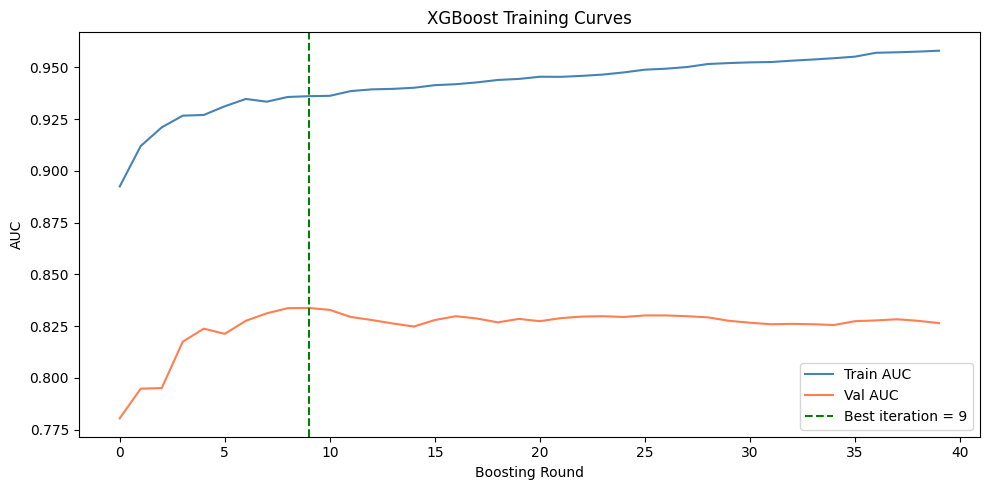

In [53]:
# ============================================================
# STEP 4: PLOT TRAINING CURVES
# ============================================================

results = xgb_model.evals_result()
train_auc = results['validation_0']['auc']
val_auc   = results['validation_1']['auc']

plt.figure(figsize=(10, 5))
plt.plot(train_auc, label='Train AUC', color='steelblue')
plt.plot(val_auc,   label='Val AUC',   color='coral')
plt.axvline(xgb_model.best_iteration, color='green',
            linestyle='--', label=f'Best iteration = {xgb_model.best_iteration}')
plt.xlabel('Boosting Round')
plt.ylabel('AUC')
plt.title('XGBoost Training Curves')
plt.legend()
plt.tight_layout()
plt.show()

In [54]:
# ============================================================
# STEP 5: EVALUATE ON TEST SET
# ============================================================
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, matthews_corrcoef
)

y_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]
y_pred_xgb  = (y_proba_xgb >= 0.5).astype(int)

print("=" * 45)
print("      XGBOOST EVALUATION ON TEST SET")
print("=" * 45)
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_proba_xgb):.4f}")
print(f"  F1 Score  : {f1_score(y_test, y_pred_xgb):.4f}")
print(f"  MCC       : {matthews_corrcoef(y_test, y_pred_xgb):.4f}")
print("=" * 45)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb,
      target_names=['No Diabetes', 'Diabetes']))

      XGBOOST EVALUATION ON TEST SET
  Accuracy  : 0.7532
  ROC-AUC   : 0.8338
  F1 Score  : 0.6885
  MCC       : 0.4975

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.86      0.74      0.80       100
    Diabetes       0.62      0.78      0.69        54

    accuracy                           0.75       154
   macro avg       0.74      0.76      0.74       154
weighted avg       0.78      0.75      0.76       154



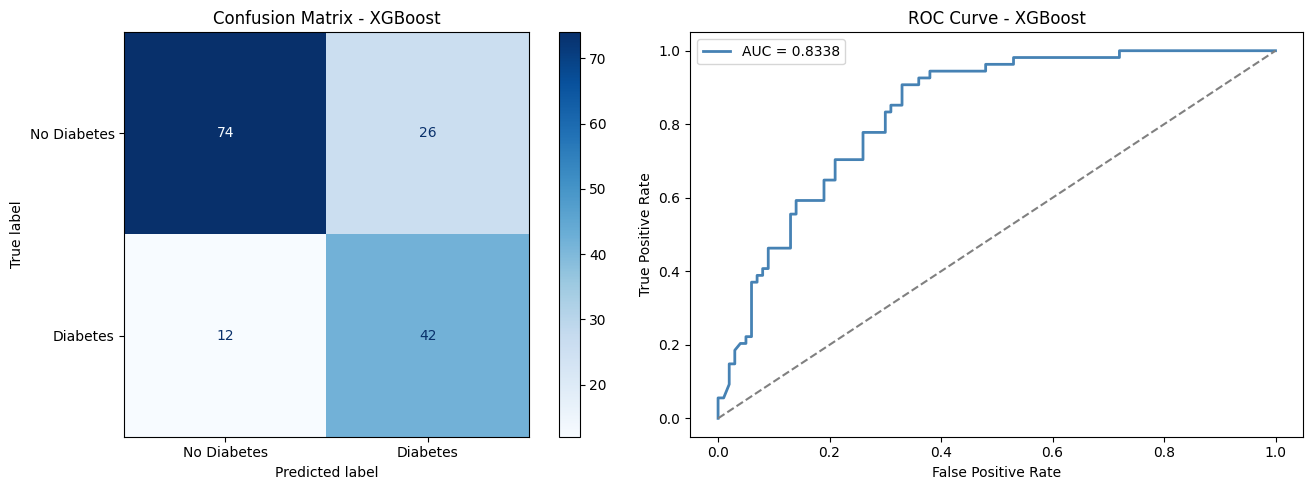

In [55]:
# ============================================================
# STEP 6: CONFUSION MATRIX + ROC CURVE
# ============================================================
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(cm, display_labels=['No Diabetes', 'Diabetes'])\
    .plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix - XGBoost')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_xgb)
axes[1].plot(fpr, tpr, color='steelblue', lw=2,
             label=f"AUC = {roc_auc_score(y_test, y_proba_xgb):.4f}")
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - XGBoost')
axes[1].legend()

plt.tight_layout()
plt.show()

Default threshold (0.5)  F1 : 0.6885
Optimal threshold (0.42) F1 : 0.7206


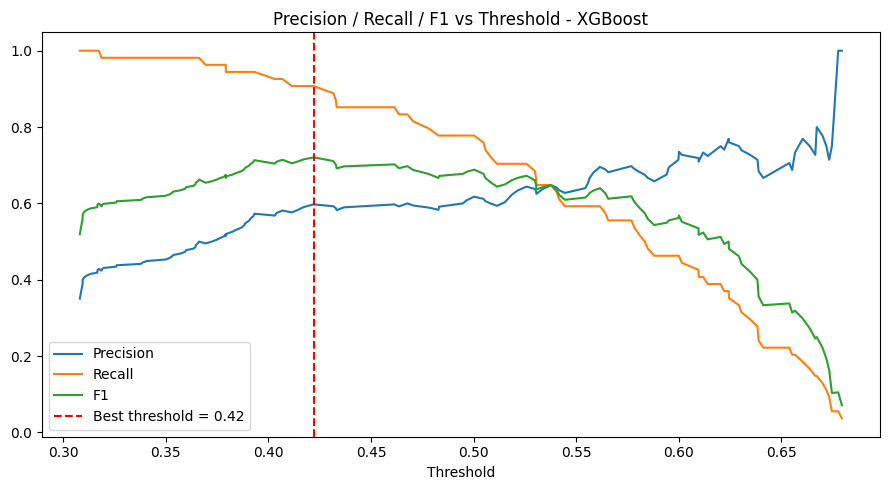


Classification Report @ Optimal Threshold:
              precision    recall  f1-score   support

 No Diabetes       0.67      0.93      0.78        72
    Diabetes       0.91      0.60      0.72        82

    accuracy                           0.75       154
   macro avg       0.79      0.76      0.75       154
weighted avg       0.80      0.75      0.75       154



In [56]:
# ============================================================
# STEP 7: OPTIMAL THRESHOLD (critical for medical data)
# ============================================================
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_xgb)
f1_scores_thresh = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_thresh = thresholds[np.argmax(f1_scores_thresh)]

print(f"Default threshold (0.5)  F1 : {f1_score(y_test, y_pred_xgb):.4f}")
print(f"Optimal threshold ({best_thresh:.2f}) F1 : "
      f"{f1_score(y_test, (y_proba_xgb >= best_thresh).astype(int)):.4f}")

# Plot
plt.figure(figsize=(9, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1],    label='Recall')
plt.plot(thresholds, f1_scores_thresh[:-1], label='F1')
plt.axvline(best_thresh, color='red', linestyle='--',
            label=f'Best threshold = {best_thresh:.2f}')
plt.xlabel('Threshold')
plt.title('Precision / Recall / F1 vs Threshold - XGBoost')
plt.legend()
plt.tight_layout()
plt.show()

# Final predictions at optimal threshold
y_pred_opt = (y_proba_xgb >= best_thresh).astype(int)
print("\nClassification Report @ Optimal Threshold:")
print(classification_report(y_pred_opt, y_test,
      target_names=['No Diabetes', 'Diabetes']))

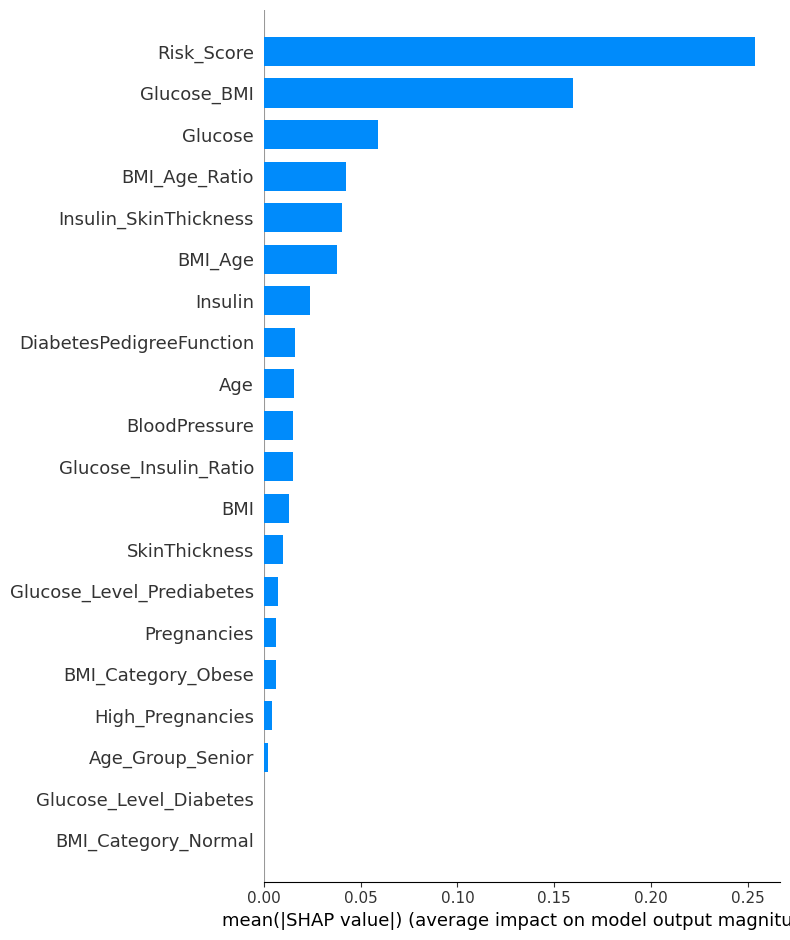

In [58]:
# ============================================================
# STEP 8: SHAP ANALYSIS
# ============================================================
import shap

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)

# --- 8a. Summary bar plot (global importance) ---
plt.figure()
shap.summary_plot(shap_values, X_test_scaled,
                  plot_type="bar",
                  feature_names=X_test_scaled.columns)



In [59]:
# ============================================================
# STEP 9: HYPERPARAMETER TUNING (GridSearchCV)
# ============================================================
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth'        : [3, 5, 7],
    'learning_rate'    : [0.01, 0.05, 0.1],
    'min_child_weight' : [1, 3, 5],
    'subsample'        : [0.7, 0.8],
    'colsample_bytree' : [0.7, 0.8],
    'gamma'            : [0, 0.1, 0.2],
}

grid_xgb = GridSearchCV(
    XGBClassifier(
        n_estimators     = 200,
        scale_pos_weight = scale_pos_weight,
        eval_metric      = 'auc',
        random_state     = 42,
        n_jobs           = -1
    ),
    param_grid,
    cv        = 5,
    scoring   = 'roc_auc',
    n_jobs    = -1,
    verbose   = 1
)

grid_xgb.fit(X_train_scaled, y_train)

print(f"\nBest params : {grid_xgb.best_params_}")
print(f"Best CV AUC : {grid_xgb.best_score_:.4f}")

# Evaluate tuned model
best_xgb    = grid_xgb.best_estimator_
y_prob_best = best_xgb.predict_proba(X_test_scaled)[:, 1]
y_pred_best = (y_prob_best >= best_thresh).astype(int)

print("\n--- Tuned XGBoost Results ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_best):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_best):.4f}")

Fitting 5 folds for each of 324 candidates, totalling 1620 fits

Best params : {'colsample_bytree': 0.7, 'gamma': 0.2, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 3, 'subsample': 0.7}
Best CV AUC : 0.8535

--- Tuned XGBoost Results ---
Accuracy : 0.7532
ROC-AUC  : 0.8259
F1 Score : 0.7031
